## Autism Prediction using (SVC, LogisticRegression, XGBClassifier) in ML Python

### 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Loading Dataset

In [2]:
url = "https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/47-Autism%20Prediction/train.csv"

In [3]:
df= pd.read_csv(url)
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


### 3. Data Preprocessing

1. Exploratory Data Analysis

In [4]:
df.shape

(800, 22)

In [5]:
df.describe()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.0000,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,28.452118,8.537303,0.201250
std,231.0844,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.310966,4.807676,0.401185
min,1.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.718550,-6.137748,0.000000
25%,200.7500,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.198153,5.306575,0.000000
50%,400.5000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.848350,9.605299,0.000000
75%,600.2500,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.865429,12.514484,0.000000
max,800.0000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.461718,15.853126,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [7]:
df.isnull().sum().sum()

np.int64(0)

2. Data Cleaning

In [8]:
df['ethnicity'].value_counts()

,count
ethnicity,
White-European,257
?,203
Middle Eastern,97
Asian,67
Black,47
South Asian,34
Pasifika,32
Others,29
Latino,17


In [9]:
df['relation'].value_counts()

,count
relation,
Self,709
?,40
Parent,29
Relative,18
Others,2
Health care professional,2


In [10]:
df = df.replace({'yes':1, 'no':0, '?':'Others', 'others':'Others'})

/tmp/ipykernel_17971/751249499.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'yes':1, 'no':0, '?':'Others', 'others':'Others'})


1.  EDA

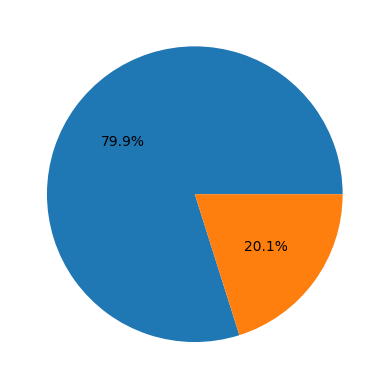

In [11]:
plt.pie(df['Class/ASD'].value_counts().values, autopct='%1.1f%%')
plt.show()

In [12]:
ints = []
objects = []
floats = []

for col in df.columns:
  if df[col].dtype == int:
    ints.append(col)
  elif df[col].dtype == object:
    objects.append(col)
  else:
    floats.append(col)

In [13]:
ints.remove('ID')
ints.remove('Class/ASD')

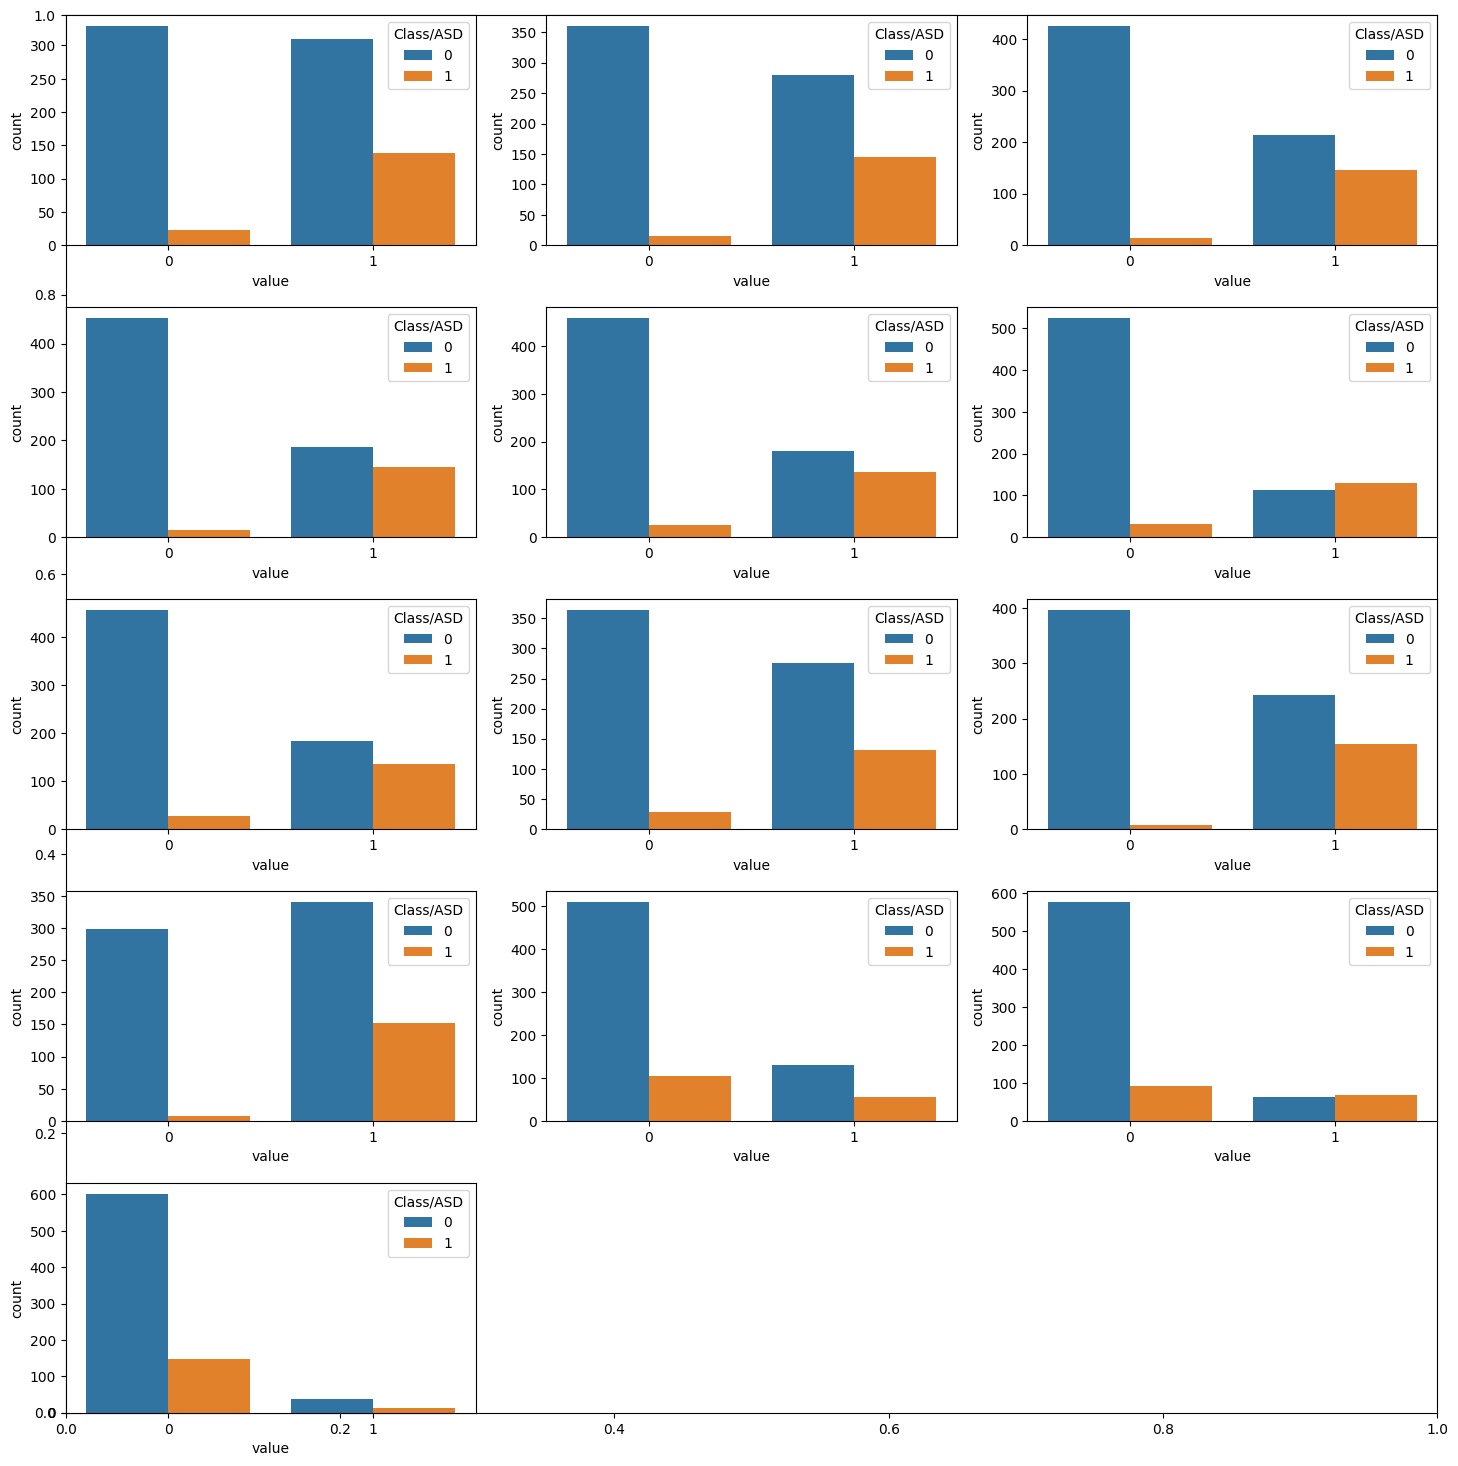

In [14]:
# Convert the data to long-form using melt
df_melted = df.melt(id_vars=['ID', 'Class/ASD'], value_vars=ints, var_name='col', value_name='value')

plt.subplots(figsize=(15,15))

for i, col in enumerate(ints):
  plt.subplot(5,3,i+1)

  sns.countplot(x='value', hue='Class/ASD', data=df_melted[df_melted['col'] == col]) 

plt.tight_layout()
plt.show()

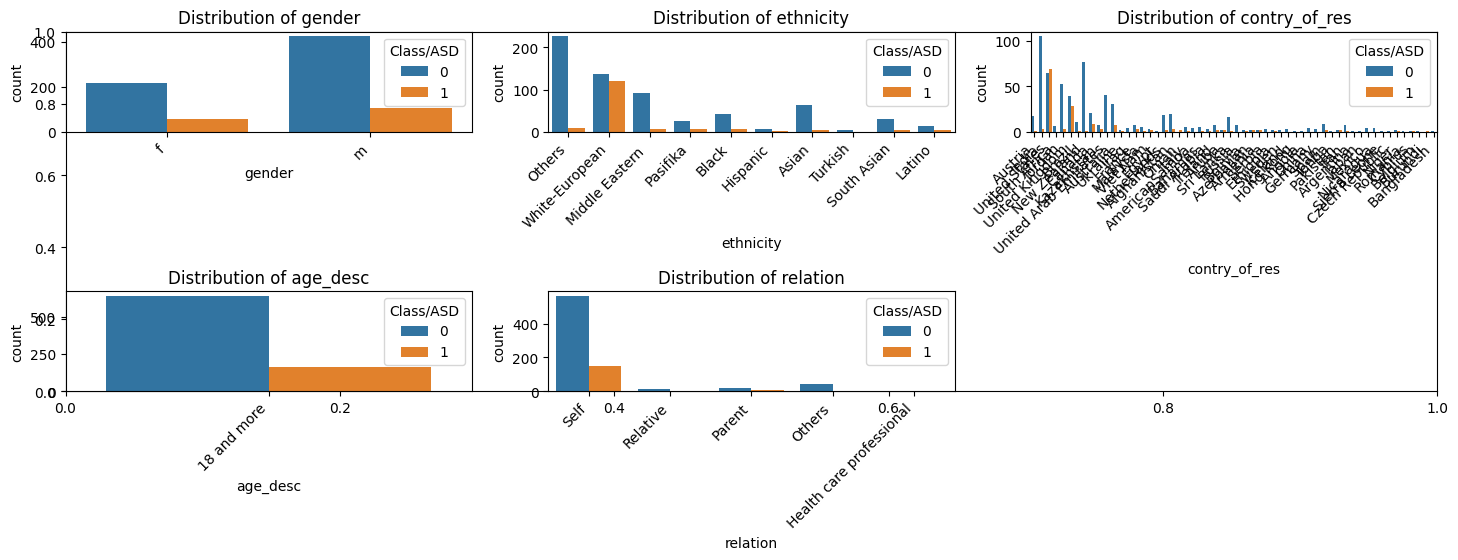

In [18]:
plt.subplots(figsize=(15, 6))  # Adjust figure size as needed

for i, col in enumerate(objects):
    plt.subplot(2, 3, i + 1)  # Adjust subplot grid as needed
    sns.countplot(x=col, hue='Class/ASD', data=df)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right') # Rotates x-axis labels for better readability

plt.tight_layout()
plt.show()

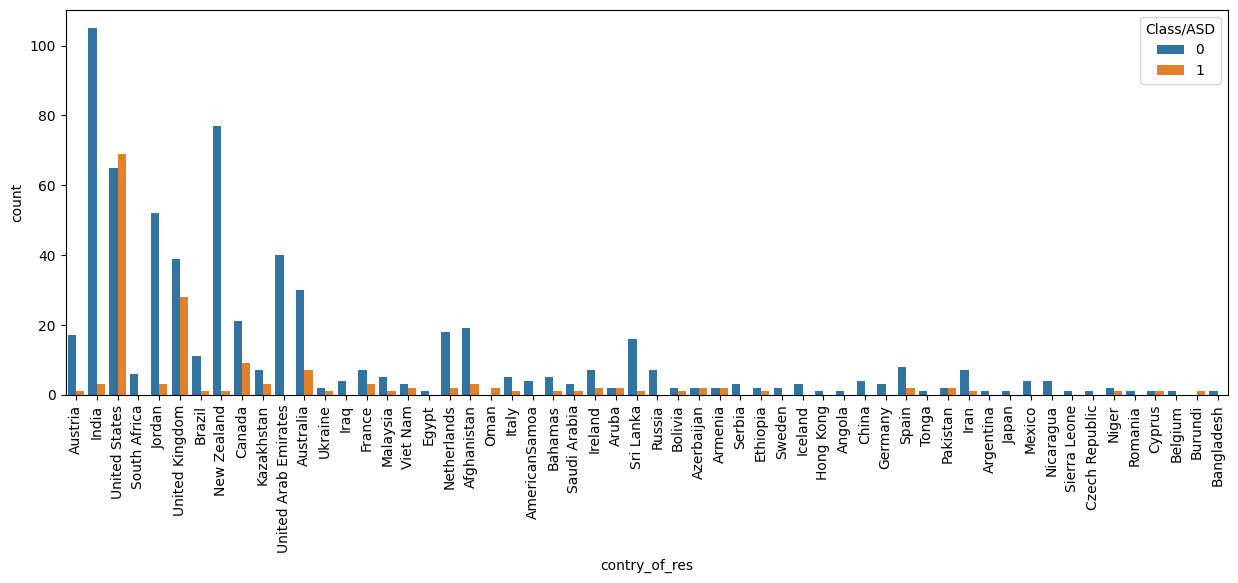

In [19]:
plt.figure(figsize=(15,5))
sns.countplot(data=df, x='contry_of_res', hue='Class/ASD')
plt.xticks(rotation=90)
plt.show()

/tmp/ipykernel_17971/3641303051.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
/tmp/ipykernel_17971/3641303051.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


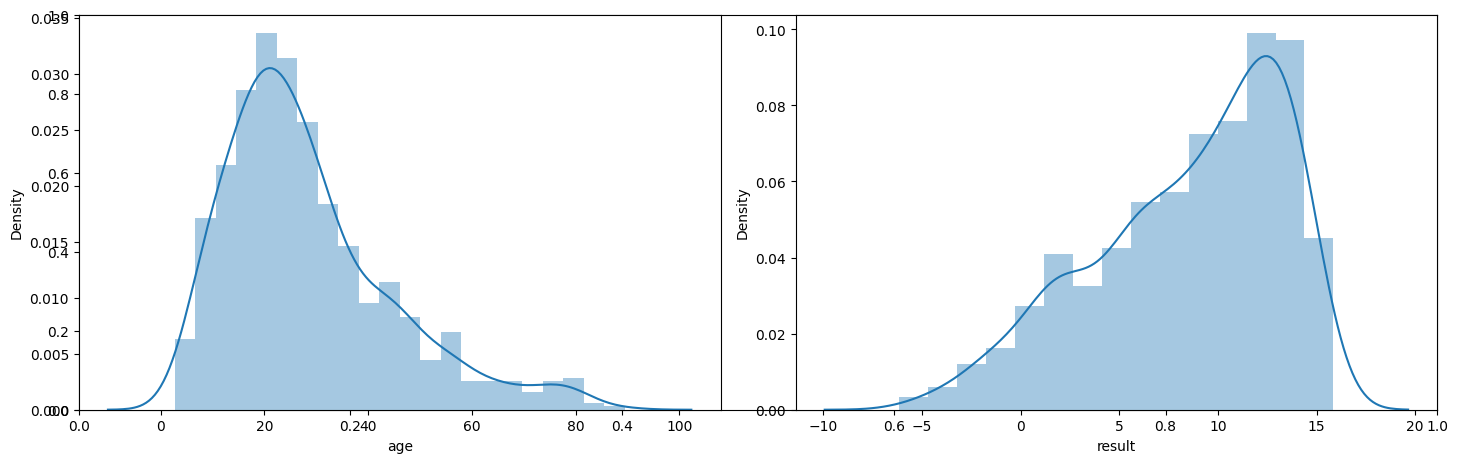

In [20]:
plt.subplots(figsize=(15,5))

for i, col in enumerate(floats):
  plt.subplot(1,2,i+1)
  sns.distplot(df[col])
plt.tight_layout()
plt.show()

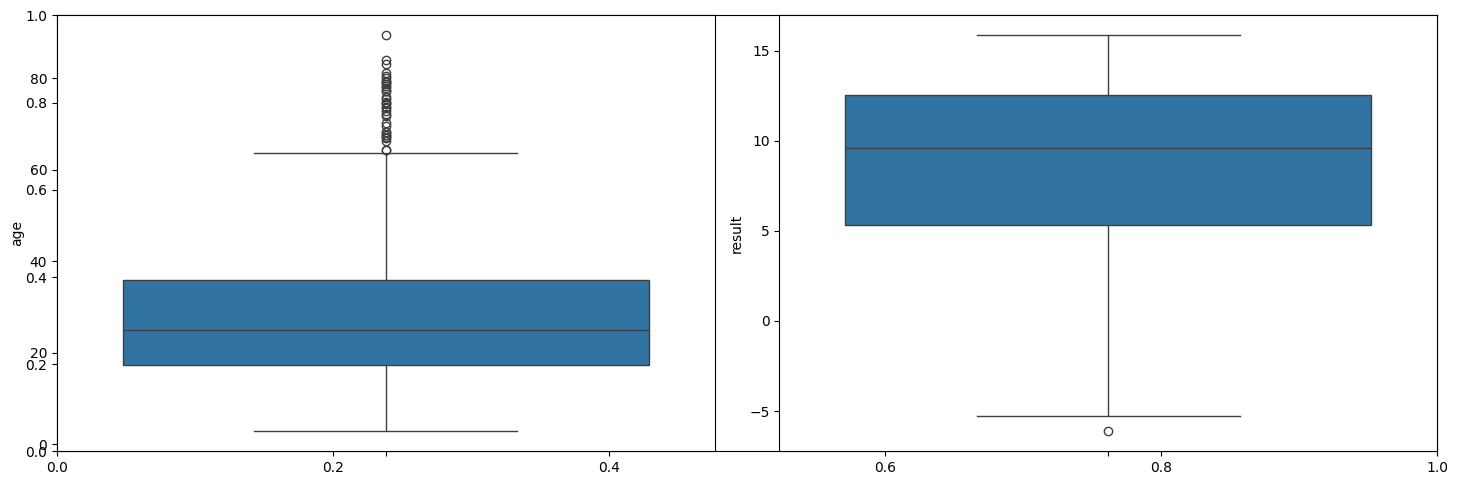

In [21]:
plt.subplots(figsize=(15,5))

for i, col in enumerate(floats):
  plt.subplot(1,2,i+1)
  sns.boxplot(df[col])
plt.tight_layout()
plt.show()

In [22]:
df = df[df['result']>-5]
df.shape

(798, 22)

3. Feature Engineering

In [23]:
def convertAge(age):
    if age < 4:
        return 'Toddler'
    elif age < 12:
        return 'Kid'
    elif age < 18:
        return 'Teenager'
    elif age < 40:
        return 'Young'
    else:
        return 'Senior'

df['ageGroup'] = df['age'].apply(convertAge)

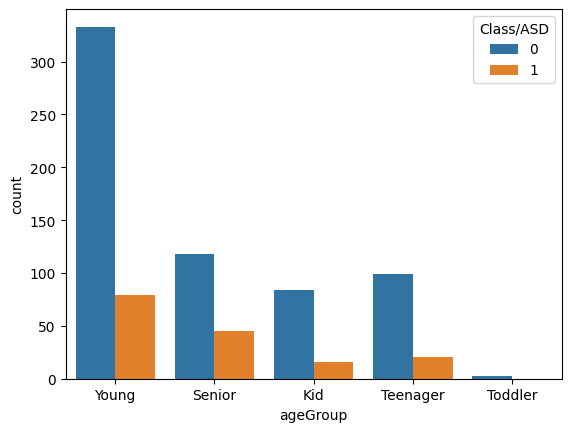

In [24]:
sns.countplot(x=df['ageGroup'], hue=df['Class/ASD'])
plt.show()

In [25]:
def add_feature(data):
  
  # Creating a column with all values zero
  data['sum_score'] = 0
  for col in data.loc[:,'A1_Score':'A10_Score'].columns:
    
    # Updating the 'sum_score' value with scores
    # from A1 to A10
    data['sum_score'] += data[col]

  # Creating a random data using the below three columns
  data['ind'] = data['austim'] + data['used_app_before'] + data['jaundice']

  return data

df = add_feature(df)

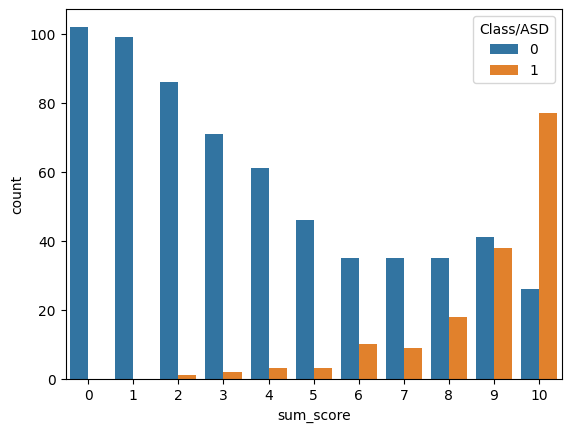

In [26]:
sns.countplot(x=df['sum_score'], hue=df['Class/ASD'])
plt.show()

In [27]:
# Applying log transformations to remove the skewness of the data.
df['age'] = df['age'].apply(lambda x: np.log(x))

/tmp/ipykernel_17971/2799180019.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'])


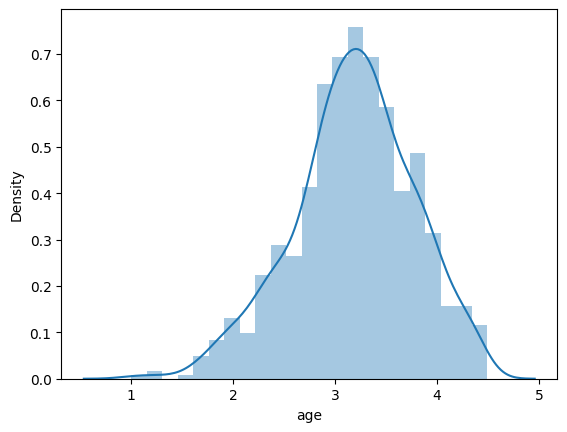

In [28]:
sns.distplot(df['age'])
plt.show()

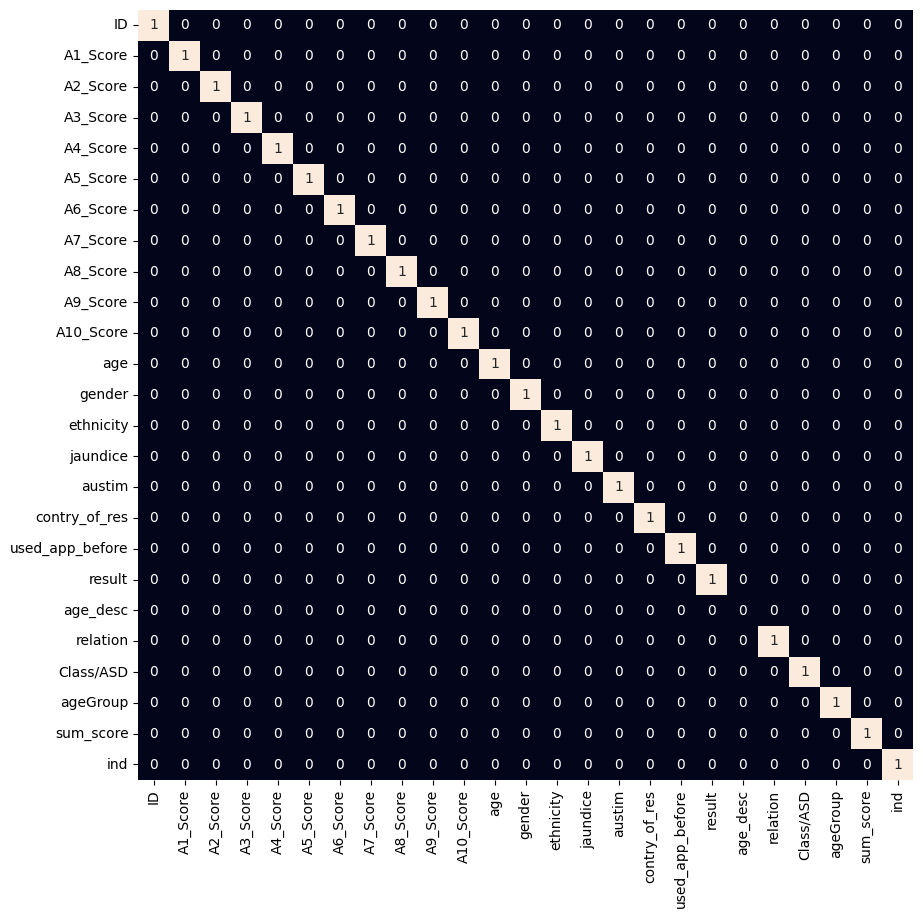

In [29]:
from sklearn.preprocessing import LabelEncoder
def encode_labels(data):
    for col in data.columns:
      
      # Here we will check if datatype
      # is object then we will encode it
      if data[col].dtype == 'object':
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
    
    return data

df = encode_labels(df)

# Making a heatmap to visualize the correlation matrix
plt.figure(figsize=(10,10))
sns.heatmap(df.corr() > 0.8, annot=True, cbar=False)
plt.show()

In [30]:
removal = ['ID', 'age_desc', 'used_app_before', 'austim']
X = df.drop(removal + ['Class/ASD'], axis=1)
y = df['Class/ASD']

4. Balance Data

In [31]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(sampling_strategy='minority',random_state=0)
X, y = ros.fit_resample(X,y)
X.shape, y.shape

((1274, 20), (1274,))

5. Train Test Split

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

6. Feature Scaling

In [33]:
from sklearn.preprocessing import StandardScaler

sc =StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### 4. Build and Fit the Models

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

models = [LogisticRegression(), XGBClassifier(), SVC(kernel='rbf')]

train_accuracy= []

for model in models:
  model.fit(X_train, y_train)
  train_auc = roc_auc_score(y_train, model.predict(X_train))
  train_accuracy.append(train_auc)
  print(f'{model} : ')
  print('Training Accuracy : ', train_auc)
  print()

LogisticRegression() : 
Training Accuracy :  0.8486559264053255

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Training Accuracy :  1.0

SVC() : 
Training Accuracy :  0.926102918515779



### 5. Make Prediction

In [35]:

test_accuracy= []

for model in models:
  model.fit(X_train, y_train)
  test_auc = roc_auc_score(y_test, model.predict(X_test))
  test_accuracy.append(test_auc)
  print(f'{model} : ')
  print('Training Accuracy : ', test_auc)
  print()

LogisticRegression() : 
Training Accuracy :  0.8321538461538461

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Training Accuracy :  0.9381538461538461

SVC() : 
Training Accuracy :  0.8996923076923077



### 6. Evaluate the Models

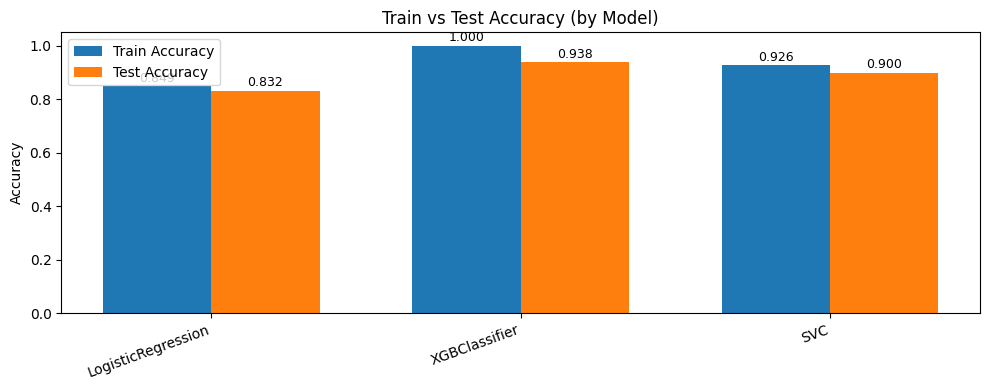

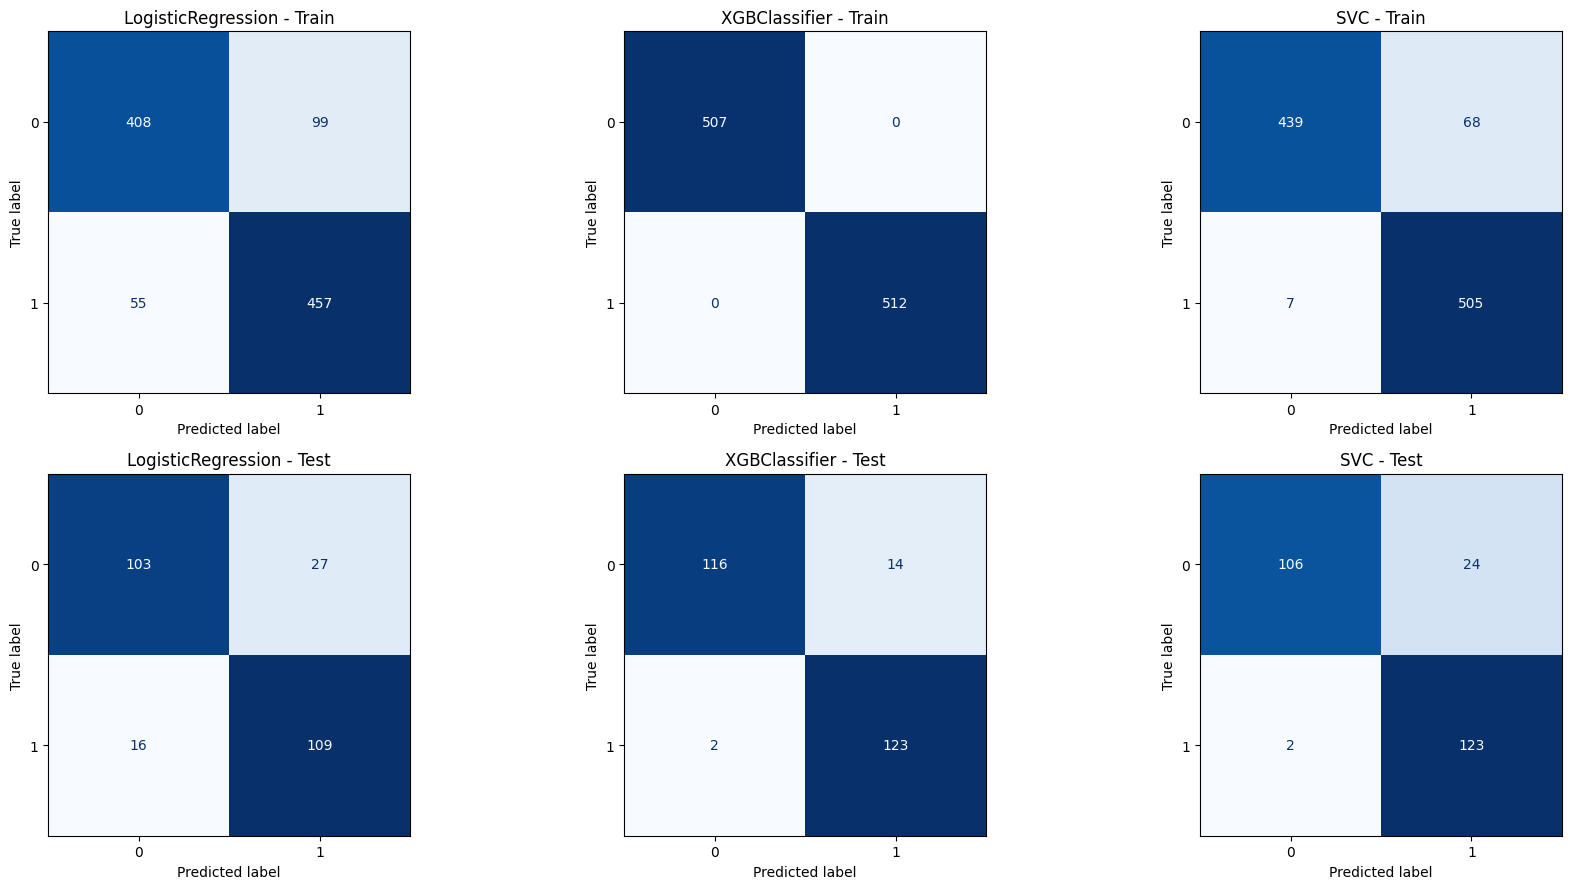

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Plot train vs test performance ---
model_names = [model.__class__.__name__ for model in models]

plt.figure(figsize=(10, 4))
x = np.arange(len(models))
width = 0.35

bars_train = plt.bar(x - width / 2, train_accuracy, width, label='Train Accuracy')
bars_test = plt.bar(x + width / 2, test_accuracy, width, label='Test Accuracy')

# Add numeric score on top of each bar
for bar in bars_train:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{bar.get_height():.3f}",
        ha='center',
        va='bottom',
        fontsize=9,
    )

for bar in bars_test:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{bar.get_height():.3f}",
        ha='center',
        va='bottom',
        fontsize=9,
    )

plt.xticks(x, model_names, rotation=20, ha='right')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy (by Model)')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

# --- Confusion matrices (train + test) ---
labels = np.unique(np.concatenate([np.asarray(y_train), np.asarray(y_test)]))

fig, axes = plt.subplots(2, len(models), figsize=(6 * len(models), 9))
axes = np.atleast_2d(axes)

for i, model in enumerate(models):
    # Train confusion matrix
    y_pred_train = model.predict(X_train)
    cm_train = confusion_matrix(y_train, y_pred_train, labels=labels)
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=labels)
    disp_train.plot(ax=axes[0, i], cmap='Blues', colorbar=False, values_format='d')
    axes[0, i].set_title(f'{model.__class__.__name__} - Train')

    # Test confusion matrix
    y_pred_test = model.predict(X_test)
    cm_test = confusion_matrix(y_test, y_pred_test, labels=labels)
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels)
    disp_test.plot(ax=axes[1, i], cmap='Blues', colorbar=False, values_format='d')
    axes[1, i].set_title(f'{model.__class__.__name__} - Test')

plt.tight_layout()
plt.show()